#UTS

Mohammad Farhan Maulana (2411500644)

Kelompok Kelas (AE)

In [1]:
!pip install tweepy

In [2]:
!pip install pandas

In [3]:
!pip install scikit-learn

In [4]:
!pip install transformers torch

In [5]:
import tweepy
import pandas as pd

BEARER_TOKEN = "AAAAAAAAAAAAAAAAAAAAABmj5QEAAAAAaXLvFlwh%2Faz93iKtplQeP5ejWcc%3Dhz0zNf7d1dJly1MTJgvbhpSx4TS4gS5xDV8aIMxP0i4x3NfWFG"

client = tweepy.Client(BEARER_TOKEN)

keyword_1 = "petani"
keyword_2 = "import beras"
keyword_3 = "petani milenial"

query = f'({keyword_1} OR "{keyword_2}" OR "{keyword_3}") -is:retweet lang:id'

print(f"Mengambil tweet dengan query: {query}\n")

try:
    response = client.search_recent_tweets(
        query=query,
        tweet_fields=["created_at", "public_metrics"],
        max_results=100
    )
    tweets_list = []
    if response.data:
        for tweet in response.data:
            tweets_list.append({
                'ID': tweet.id,
                'Waktu': tweet.created_at,
                'Tweets': tweet.text,
                'Jumlah Retweet': tweet.public_metrics['retweet_count'],
                'Jumlah Suka': tweet.public_metrics['like_count']
            })
    df = pd.DataFrame(tweets_list)
    print("Data berhasil dikumpulkan:")
    display(df.head())

except Exception as e:
    print(f"Error saat mengambil data: {e}")

    display(df)


Mengambil tweet dengan query: (petani OR "import beras" OR "petani milenial") -is:retweet lang:id

Data berhasil dikumpulkan:


,ID,Waktu,Tweets,Jumlah Retweet,Jumlah Suka
0,1988501765814133007,2025-11-12 06:59:00+00:00,Penertiban Kebun Sawit dalam Kawasan Hutan Jan...,0,0
1,1988501418756714496,2025-11-12 06:57:37+00:00,@flowerofRM @rafenditya @FOODFESS2 halo kak ka...,0,0
2,1988500998525251938,2025-11-12 06:55:57+00:00,BRMP Padi berkomitmen mendukung kemandirian be...,0,0
3,1988500470638207192,2025-11-12 06:53:51+00:00,BRMP Padi berkomitmen agar hasil riset dan ino...,0,0
4,1988500463935766575,2025-11-12 06:53:49+00:00,Melalui layanan pendayagunaan hasil perakitan ...,0,0


In [6]:
import re
import string

def bersihkan_teks(teks):
    teks = teks.lower()

    teks = re.sub(r'http\S+|www\S+|https\S+', '', teks, flags=re.MULTILINE)

    teks = re.sub(r'\@\w+', '', teks)

    teks = re.sub(r'\#\w+', '', teks)

    teks = teks.translate(str.maketrans('', '', string.punctuation))

    teks = re.sub(r'\d+', '', teks)

    teks = ' '.join(teks.split())

    return teks

df['Cleaned'] = df['Tweets'].apply(bersihkan_teks)

print("Hasil Pre-processing (5 Tweet Pertama):")
display(df[['Tweets', 'Cleaned']].head(5))

Hasil Pre-processing (5 Tweet Pertama):


,Tweets,Cleaned
0,Penertiban Kebun Sawit dalam Kawasan Hutan Jan...,penertiban kebun sawit dalam kawasan hutan jan...
1,@flowerofRM @rafenditya @FOODFESS2 halo kak ka...,halo kak kamu domisili mana yaa kebetulan aku ...
2,BRMP Padi berkomitmen mendukung kemandirian be...,brmp padi berkomitmen mendukung kemandirian be...
3,BRMP Padi berkomitmen agar hasil riset dan ino...,brmp padi berkomitmen agar hasil riset dan ino...
4,Melalui layanan pendayagunaan hasil perakitan ...,melalui layanan pendayagunaan hasil perakitan ...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df['Cleaned'])

feature_names = tfidf_vectorizer.get_feature_names_out()

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("Matriks Fitur TF-IDF (Hasil Ekstraksi):")
display(df_tfidf)

print("\nFitur yang Diekstrak (Skor TF-IDF) untuk 5 Tweet Pertama:")

for i in range(5):
    if i >= len(df):
        break

    print(f"\n--- Tweet {i+1} ---")
    print(f"Teks Asli: {df.iloc[i]['Cleaned']}")

    feature_scores = {
        'Fitur (Kata)': [],
        'Skor TF-IDF': []
    }

    for col in df_tfidf.columns:
        score = df_tfidf.iloc[i][col]
        if score > 0:
            feature_scores['Fitur (Kata)'].append(col)
            feature_scores['Skor TF-IDF'].append(score)

    df_scores = pd.DataFrame(feature_scores)
    display(df_scores.sort_values(by='Skor TF-IDF', ascending=False))

Matriks Fitur TF-IDF (Hasil Ekstraksi):


,abai,abang,ada,adalah,adek,adi,agar,agik,agunan,agung,...,workshop,wujud,wujudkan,ya,yaa,yaaa,yang,yg,zakia,zaman
0,0.348902,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.193281,0.0,0.000000,0.000000,0.0,0.000000
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.087395,0.000000,0.0,0.000000
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.239352,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
96,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000
97,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.105819,0.000000,0.0,0.000000,0.175015,0.0,0.000000
98,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.179476,0.0,0.000000,0.000000,0.0,0.189474



Fitur yang Diekstrak (Skor TF-IDF) untuk 5 Tweet Pertama:

--- Tweet 1 ---
Teks Asli: penertiban kebun sawit dalam kawasan hutan jangan abai petani


,Fitur (Kata),Skor TF-IDF
2,hutan,0.380224
8,sawit,0.380224
4,kawasan,0.380224
6,penertiban,0.380224
0,abai,0.348902
5,kebun,0.348902
3,jangan,0.348902
1,dalam,0.224572
7,petani,0.078019



--- Tweet 2 ---
Teks Asli: halo kak kamu domisili mana yaa kebetulan aku lg cari petani jahe apakah bapak kamu masih jadi petani jahe nderr


...

,Fitur (Kata),Skor TF-IDF
1,benih,0.494172
26,publik,0.179512
3,berbagai,0.179512
5,bermutu,0.179512
12,diakses,0.179512
16,kemandirian,0.179512
31,unggul,0.179512
21,mendukung,0.179512
23,percaya,0.179512
30,tingkat,0.179512



--- Tweet 4 ---
Teks Asli: brmp padi berkomitmen agar hasil riset dan inovasi tidak hanya berhenti di laboratorium tetapi hadir nyata di lapangan memberi manfaat langsung bagi petani dan masyarakat luas


,Fitur (Kata),Skor TF-IDF
0,agar,0.239352
14,luas,0.239352
15,manfaat,0.239352
11,laboratorium,0.239352
22,tetapi,0.239352
2,berhenti,0.219634
3,berkomitmen,0.219634
21,riset,0.219634
10,inovasi,0.219634
23,tidak,0.219634



--- Tweet 5 ---
Teks Asli: melalui layanan pendayagunaan hasil perakitan dan modernisasi pertanian padi brmp padi membuka akses bagi masyarakat petani pelajar peneliti dan mitra kerja untuk belajar berkonsultasi serta menerapkan teknologi pertanian secara langsung


,Fitur (Kata),Skor TF-IDF
16,padi,0.279805
21,pertanian,0.279805
3,berkonsultasi,0.214034
13,menerapkan,0.214034
15,modernisasi,0.214034
17,pelajar,0.214034
18,pendayagunaan,0.214034
12,membuka,0.196403
14,mitra,0.196403
2,belajar,0.196403


In [8]:
from transformers import pipeline
import pandas as pd

MODEL_NAME = "w11wo/indonesian-roberta-base-sentiment-classifier"

print(f"Memuat pipeline dengan model ({MODEL_NAME})...")

try:
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model=MODEL_NAME,
        tokenizer=MODEL_NAME
    )

    print("Model berhasil dimuat.")
    print("-" * 30)

    def get_sentiment_roberta(teks):
        try:
            if not teks.strip():
                return 'Netral'

            result = sentiment_pipeline(teks)
            label = result[0]['label']

            if label == 'positive':
                return 'Positif'
            elif label == 'negative':
                return 'Negatif'
            else:
                return 'Netral'

        except Exception as e:
            if "too long" in str(e):
                teks_terpotong = teks[:512]
                result = sentiment_pipeline(teks_terpotong)
                label = result[0]['label']

                if label == 'positive':
                    return 'Positif'
                elif label == 'negative':
                    return 'Negatif'
                else:
                    return 'Netral'

            print(f"Error processing text: {teks} - {e}")
            return "Gagal Proses"

    df['Sentiment'] = df['Cleaned'].apply(get_sentiment_roberta)

    print("\nHasil Analisis Sentimen (5 Tweet Pertama):")
    display(df[['Cleaned', 'Sentiment']].head(5))

    print("\nDistribusi Sentimen di Seluruh Data:")
    display(df['Sentiment'].value_counts())

except Exception as e:
    print(f"GAGAL MEMUAT MODEL. Error: {e}")
    print("Pastikan Anda memiliki koneksi internet untuk mengunduh model.")

Memuat pipeline dengan model (w11wo/indonesian-roberta-base-sentiment-classifier)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/328 [00:00<?, ?B/s]

...

Device set to use cpu


Model berhasil dimuat.
------------------------------

Hasil Analisis Sentimen (5 Tweet Pertama):


,Cleaned,Sentiment
0,penertiban kebun sawit dalam kawasan hutan jan...,Netral
1,halo kak kamu domisili mana yaa kebetulan aku ...,Netral
2,brmp padi berkomitmen mendukung kemandirian be...,Positif
3,brmp padi berkomitmen agar hasil riset dan ino...,Positif
4,melalui layanan pendayagunaan hasil perakitan ...,Netral



Distribusi Sentimen di Seluruh Data:


,count
Sentiment,
Netral,54
Negatif,24
Positif,22



--- Visualisasi Distribusi Sentimen ---

Visualisasi diagram lingkaran berwarna telah disimpan.


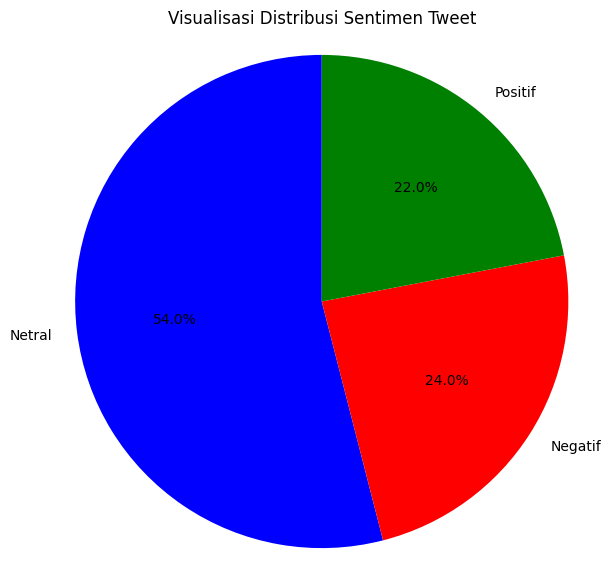

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

print("\n--- Visualisasi Distribusi Sentimen ---")

sentiment_counts = df['Sentiment'].value_counts()

color_map = {
    'Positif': 'green',
    'Netral': 'blue',
    'Negatif': 'red'
}

plot_colors = sentiment_counts.index.map(color_map).fillna('gray')

plt.figure(figsize=(7, 7))

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plot_colors
)

plt.title('Visualisasi Distribusi Sentimen Tweet')
plt.axis('equal')

plt.savefig('distribusi_sentimen_pie.png')

print("\nVisualisasi diagram lingkaran berwarna telah disimpan.")


--- Visualisasi Distribusi Sentimen ---

Visualisasi diagram batang berwarna telah disimpan.


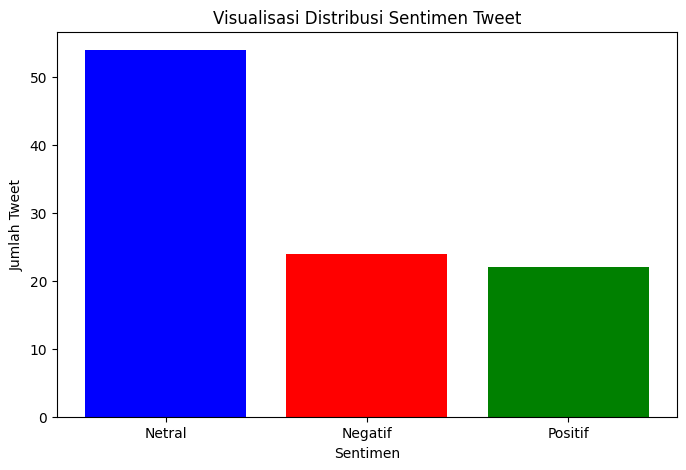

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

print("\n--- Visualisasi Distribusi Sentimen ---")

sentiment_counts = df['Sentiment'].value_counts()

color_map = {
    'Positif': 'green',
    'Netral': 'blue',
    'Negatif': 'red'
}

plot_colors = sentiment_counts.index.map(color_map).fillna('gray')

plt.figure(figsize=(8, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=plot_colors
)

plt.title('Visualisasi Distribusi Sentimen Tweet')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Tweet')

plt.savefig('distribusi_sentimen_barchart.png')

print("\nVisualisasi diagram batang berwarna telah disimpan.")